In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import sqlite3
import folium
from geopy.geocoders import Nominatim
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [6]:
conn = sqlite3.connect('yelp.db')

In [7]:
tables = pd.read_sql_query("SELECT name from sqlite_master WHERE type = 'table'", conn)

In [8]:
tables

,name
0,business
1,checkin
2,tip
3,user
4,review


In [10]:
for table in tables['name']:
    display(pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [11]:
pd.read_sql_query("select count(*) from business", conn)

,count(*)
0,150346


In [26]:
business_id = pd.read_sql_query("""select business_id, review_count from business where lower(categories) like '%restaurant%' and is_open = 1""", conn)

In [23]:
#avg, min, max, median
pd.read_sql_query(f"""SELECT 
AVG(review_count), 
MIN(review_count), 
MAX(review_count), 
(SELECT review_count FROM business ORDER BY review_count LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) /2) as median_review_count, 

AVG(stars), 
MIN(stars), 
MAX(stars), 
(SELECT stars FROM business ORDER BY stars LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) /2) as median_star_rating 


FROM business 
WHERE business_id IN {tuple(business_id['business_id'])}""", conn).transpose()

,0
AVG(review_count),104.097789
MIN(review_count),5.000000
MAX(review_count),7568.000000
median_review_count,15.000000
AVG(stars),3.523969
MIN(stars),1.000000
MAX(stars),5.000000
median_star_rating,3.500000


In [18]:
#df = pd.read_sql_query("SELECT review_count FROM business", conn)
#print(df['review_count'].median())

15.0


In [24]:
#function to remove outliers
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 -q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [27]:
business_id = remove_outliers(business_id, 'review_count')

In [29]:
business_id.shape

(31537, 2)

In [30]:
#avg, min, max, median after removing outliers
pd.read_sql_query(f"""SELECT 
AVG(review_count), 
MIN(review_count), 
MAX(review_count), 
(SELECT review_count FROM business ORDER BY review_count LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) /2) as median_review_count, 

AVG(stars), 
MIN(stars), 
MAX(stars), 
(SELECT stars FROM business ORDER BY stars LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) /2) as median_star_rating 


FROM business 
WHERE business_id IN {tuple(business_id['business_id'])}""", conn).transpose()

,0
AVG(review_count),55.975426
MIN(review_count),5.000000
MAX(review_count),248.000000
median_review_count,15.000000
AVG(stars),3.477281
MIN(stars),1.000000
MAX(stars),5.000000
median_star_rating,3.500000


In [32]:
#top 10 most reviewed restaurants
pd.read_sql_query(f"""SELECT name, SUM(review_count) AS review_count, AVG(stars) AS avg_rating 
FROM business 
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY name
ORDER BY review_count DESC
LIMIT 10
""", conn)

,name,review_count,avg_rating
0,McDonald's,16490,1.868702
1,Chipotle Mexican Grill,9071,2.381757
2,Taco Bell,8017,2.141813
3,Chick-fil-A,7687,3.377419
4,First Watch,6761,3.875000
5,Panera Bread,6613,2.661905
6,Buffalo Wild Wings,6483,2.344828
7,Domino's Pizza,6091,2.290210
8,Wendy's,5930,2.030159
9,Chili's,5744,2.514706


In [33]:
#top 10 highest rated restaurants
pd.read_sql_query(f"""SELECT name, SUM(review_count) AS review_count, AVG(stars) AS avg_rating 
FROM business 
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY name
ORDER BY avg_rating DESC
LIMIT 10
""", conn)

,name,review_count,avg_rating
0,ā café,48,5.0
1,two birds cafe,77,5.0
2,the brewers cabinet production,13,5.0
3,taqueria la cañada,17,5.0
4,la bamba,44,5.0
5,la 5th av tacos,24,5.0
6,el sabor mexican and chinese food,21,5.0
7,eat.drink.Om...YOGA CAFE,7,5.0
8,d4 Tabletop Gaming Cafe,8,5.0
9,cabbage vegetarian cafe,12,5.0


In [36]:
#relation between engagement and ratings
pd.read_sql_query("""SELECT business_id,
sum(length(date)-length(replace(date, ',', ''))+1) as checkin_count
FROM checkin
GROUP BY business_id
""", conn)

,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11
1,--0iUa4sNDFiZFrAdIWhZQ,10
2,--30_8IhuyMHbSOcNWd6DQ,2
3,--7PUidqRWpRSpXebiyxTg,10
4,--7jw19RH9JKXgFohspgQw,26
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,67
131926,zznZqH9CiAznbkV6fXyHWA,1
131927,zzu6_r3DxBJuXcjnOYVdTw,23
131928,zzw66H6hVjXQEt0Js3Mo4A,2


In [39]:
pd.read_sql_query("""SELECT business_id, count(*) AS tip_count
FROM tip
GROUP BY business_id
""", conn)

,business_id,tip_count
0,---kPU91CF4Lq2-WlRu9Lw,4
1,--0iUa4sNDFiZFrAdIWhZQ,6
2,--30_8IhuyMHbSOcNWd6DQ,1
3,--7PUidqRWpRSpXebiyxTg,3
4,--8IbOsAAxjKRoYsBFL-PA,4
...,...,...
106188,zzjCxn89a7RQo8keIOO_Ag,1
106189,zzjFdJwXuxBOGe9JeY_EMw,2
106190,zznJox6-nmXlGYNWgTDwQQ,6
106191,zzu6_r3DxBJuXcjnOYVdTw,2


In [45]:
review_count_df = pd.read_sql_query(f"""SELECT total.avg_rating AS rating, 
AVG(total.review_count) AS avg_review_count,
AVG(total.checkin_count) AS avg_checkin_count,
AVG(total.tip_count) AS avg_tip_count
FROM 
(SELECT 
    b.business_id,
    SUM(b.review_count) AS review_count,
    AVG(b.stars) AS avg_rating,
    SUM(LENGTH(c.date)-LENGTH(REPLACE(c.date, ',', ''))+1) AS checkin_count,
    SUM(tip.tip_count) AS tip_count
FROM
    business b
LEFT JOIN
    checkin c ON b.business_id = c.business_id
LEFT JOIN
    (SELECT business_id, COUNT(business_id) AS tip_count FROM tip GROUP BY business_id ORDER BY tip_count) AS tip ON b.business_id = tip.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY
    b.business_id) AS total
    
GROUP BY total.avg_rating
""", conn)

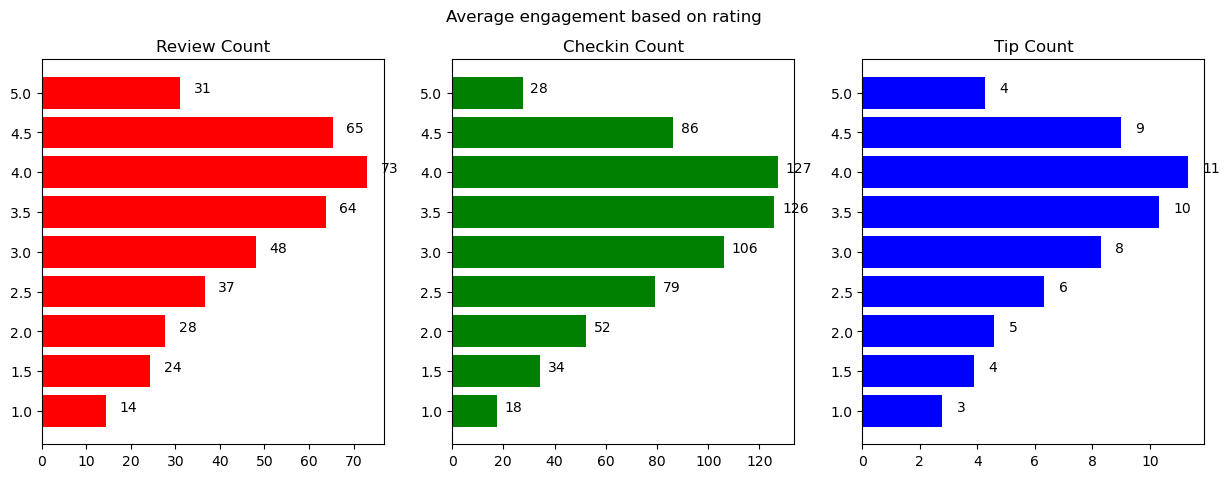

In [58]:
plt.figure(figsize=(15,5))
plt.suptitle('Average engagement based on rating\n\n')
plt.subplot(1,3,1)
plt.title('Review Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_review_count'], color = 'red')
for i, value in enumerate(review_count_df['avg_review_count']):
    plt.text(value+3, i, str(round(value)))

plt.subplot(1,3,2)
plt.title('Checkin Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_checkin_count'], color = 'green')
for i, value in enumerate(review_count_df['avg_checkin_count']):
    plt.text(value+3, i, str(round(value)))
    
plt.subplot(1,3,3)
plt.title('Tip Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_tip_count'], color = 'blue')
for i, value in enumerate(review_count_df['avg_tip_count']):
    plt.text(value+0.5, i, str(round(value)))
    
plt.show()

In [65]:
#relation between reviews, checkins and tips
engagement_df = pd.read_sql_query(f"""SELECT 
    b.business_id,
    SUM(b.review_count) AS review_count,
    AVG(b.stars) AS avg_rating,
    SUM(LENGTH(c.date)-LENGTH(REPLACE(c.date, ',', ''))+1) AS checkin_count,
    SUM(tip.tip_count) AS tip_count
FROM
    business b
LEFT JOIN
    checkin c ON b.business_id = c.business_id
LEFT JOIN
    (SELECT business_id, COUNT(business_id) AS tip_count FROM tip GROUP BY business_id ORDER BY tip_count) AS tip ON b.business_id = tip.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY
    b.business_id
    
""", conn).dropna()

In [68]:
engagement_df[['review_count', 'checkin_count', 'tip_count']].corr()

,review_count,checkin_count,tip_count
review_count,1.000000,0.626884,0.766321
checkin_count,0.626884,1.000000,0.772088
tip_count,0.766321,0.772088,1.000000


<AxesSubplot:>

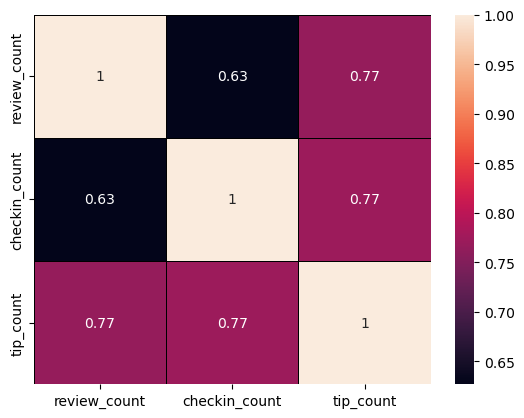

In [76]:
sns.heatmap(engagement_df[['review_count', 'checkin_count', 'tip_count']].corr(), annot=True, linewidth=0.7, linecolor='black')

In [82]:
#differences in engagement between high and low rated businesses
engagement_df = pd.read_sql_query(f"""SELECT 
    b.business_id,
    SUM(b.review_count) AS review_count,
    AVG(b.stars) AS avg_rating,
    SUM(LENGTH(c.date)-LENGTH(REPLACE(c.date, ',', ''))+1) AS checkin_count,
    SUM(tip.tip_count) AS tip_count,
    (CASE WHEN b.stars >= 3.5 THEN 'High-rated' ELSE 'Low-rated' END) as category
FROM
    business b
LEFT JOIN
    checkin c ON b.business_id = c.business_id
LEFT JOIN
    (SELECT business_id, COUNT(business_id) AS tip_count FROM tip GROUP BY business_id ORDER BY tip_count) AS tip ON b.business_id = tip.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY
    b.business_id
    
""", conn).dropna()

In [83]:
engagement_df.groupby("category")[['review_count', 'checkin_count', 'tip_count']].mean()

,review_count,checkin_count,tip_count
category,,,
High-rated,72.291062,122.066641,10.162766
Low-rated,42.123420,88.880828,6.541689


In [84]:
# function to calculate success score based on average rating and review count
def calculate_success_metric(df):
    success_score = []
    for index, row in df.iterrows():
        score = row['avg_rating'] * np.log(row['review_count'] + 1)
        success_score.append(score)
    return success_score

In [86]:
# how do the success metrics (reviews and ratings) vary across locations (city/state)
city_df = pd.read_sql_query(f"""SELECT city, state, latitude, longitude, AVG(stars) AS avg_rating, 
SUM(review_count) AS review_count, COUNT(*) AS restaurant_count 
FROM business 
WHERE business_id IN {tuple(business_id['business_id'])} 
GROUP BY state, city
ORDER BY review_count DESC
LIMIT 10
""", conn)

city_df['success_score'] = calculate_success_metric(city_df)

In [87]:
city_df

,city,state,latitude,longitude,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,39.955505,-75.155564,3.532156,175487,3001,42.651934
1,Tampa,FL,27.890814,-82.502346,3.571429,104376,1715,41.270588
2,Indianapolis,IN,39.637133,-86.127217,3.412111,92639,1701,39.022521
3,Tucson,AZ,32.338572,-111.010760,3.386187,91613,1419,38.688341
4,Nashville,TN,36.208102,-86.768170,3.493590,87070,1404,39.737764
5,New Orleans,LA,29.963974,-90.042604,3.693676,69239,1012,41.167252
6,Saint Louis,MO,38.583223,-90.407187,3.414303,51490,811,37.042331
7,Reno,NV,39.476518,-119.784037,3.479626,48393,589,37.535187
8,Edmonton,AB,53.436403,-113.604288,3.509379,45916,1546,37.671748
9,Boise,ID,43.611192,-116.206275,3.558824,36104,561,37.346958


In [100]:
# creating map
m = folium.Map(location = [city_df['latitude'].mean(), city_df['longitude'].mean()], zoom_start = 4)

color_scale = folium.LinearColormap(colors = ['red', 'yellow', 'green'], 
                               vmin=city_df['success_score'].min(), 
                               vmax=city_df['success_score'].max())

for index, row in city_df.iterrows():
    folium.CircleMarker(location=[row['latitude'], row['longitude']],
                       color=color_scale(row['success_score']),
                        fill = True
                       ).add_to(m)
    
m.add_child(color_scale)
m

In [103]:
# analysing time patterns of engagement for businesses based on their success
# analysing seasonal trends in engagement

high_rated_engagement = pd.read_sql_query(f"""
SELECT review.month_year, review.review_count, tip.tip_count FROM
(SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
FROM review
WHERE business_id IN {tuple(business_id['business_id'])} AND stars >= 3.5
GROUP BY month_year
ORDER BY month_year) AS review
JOIN
(SELECT AVG(b.stars), strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
FROM tip
JOIN business AS b
ON tip.business_id = b.business_id
WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars >= 3.5
GROUP BY month_year
ORDER BY month_year) AS tip

ON review.month_year = tip.month_year;
""", conn)

low_rated_engagement = pd.read_sql_query(f"""
SELECT review.month_year, review.review_count, tip.tip_count FROM
(SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
FROM review
WHERE business_id IN {tuple(business_id['business_id'])} AND stars < 3.5
GROUP BY month_year
ORDER BY month_year) AS review
JOIN
(SELECT AVG(b.stars), strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
FROM tip
JOIN business AS b
ON tip.business_id = b.business_id
WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars < 3.5
GROUP BY month_year
ORDER BY month_year) AS tip

ON review.month_year = tip.month_year;
""", conn)

In [104]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,1218,79
1,01-2011,2171,621
2,01-2012,3086,1321
3,01-2013,3801,1230
4,01-2014,4973,1357
...,...,...,...
149,12-2017,10161,1477
150,12-2018,12870,1163
151,12-2019,13756,1161
152,12-2020,11294,937


In [105]:
low_rated_engagement

,month_year,review_count,tip_count
0,01-2010,613,25
1,01-2011,1103,297
2,01-2012,1748,538
3,01-2013,2196,548
4,01-2014,2769,607
...,...,...,...
149,12-2017,5970,441
150,12-2018,7574,338
151,12-2019,7591,275
152,12-2020,5014,148


In [108]:
time_rating = pd.read_sql_query(f"""SELECT strftime('%m-%Y', date) AS month_year, AVG(stars) AS avg_rating
FROM review
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY month_year
ORDER BY month_year;
""", conn)

In [109]:
time_rating

,month_year,avg_rating
0,01-2006,4.000000
1,01-2007,3.897436
2,01-2008,3.603960
3,01-2009,3.690661
4,01-2010,3.724194
...,...,...
198,12-2017,3.613415
199,12-2018,3.608687
200,12-2019,3.665246
201,12-2020,3.833701


In [111]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year', inplace = True)
time_rating = time_rating[time_rating['month_year']>pd.to_datetime('2017-12-31')]

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year', inplace = True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year']>pd.to_datetime('2017-12-31')]

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year', inplace = True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year']>pd.to_datetime('2017-12-31')]

In [112]:
high_rated_engagement['avg_rating'] = time_rating['avg_rating'].values

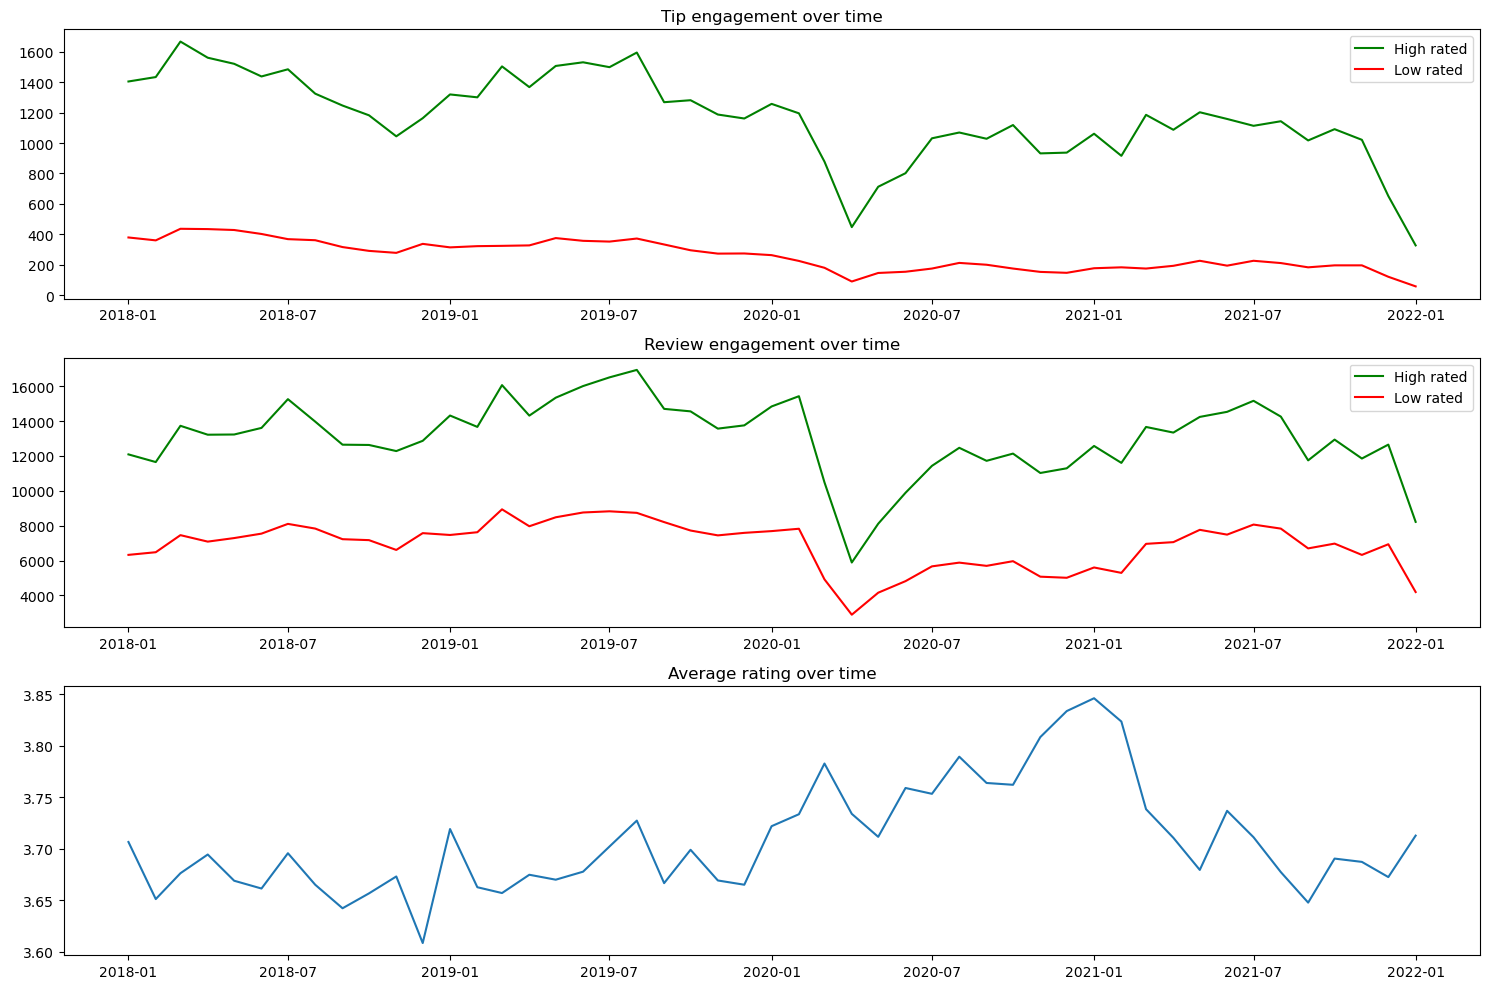

In [129]:
plt.figure(figsize = (15,10))

plt.subplot(3,1,1)
plt.title('Tip engagement over time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'], label = 'High rated', color = 'green')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['tip_count'], label = 'Low rated', color = 'red')
plt.legend()

plt.subplot(3,1,2)
plt.title('Review engagement over time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'], label = 'High rated', color = 'green')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['review_count'], label = 'Low rated', color = 'red')
plt.legend()

plt.subplot(3,1,3)
plt.title('Average rating over time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['avg_rating'])
plt.tight_layout()
plt.show()

In [132]:
tip_high_rated = high_rated_engagement[['month_year', 'tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year', 'review_count']].set_index('month_year')
rating_df = time_rating[['month_year', 'avg_rating']].set_index('month_year')

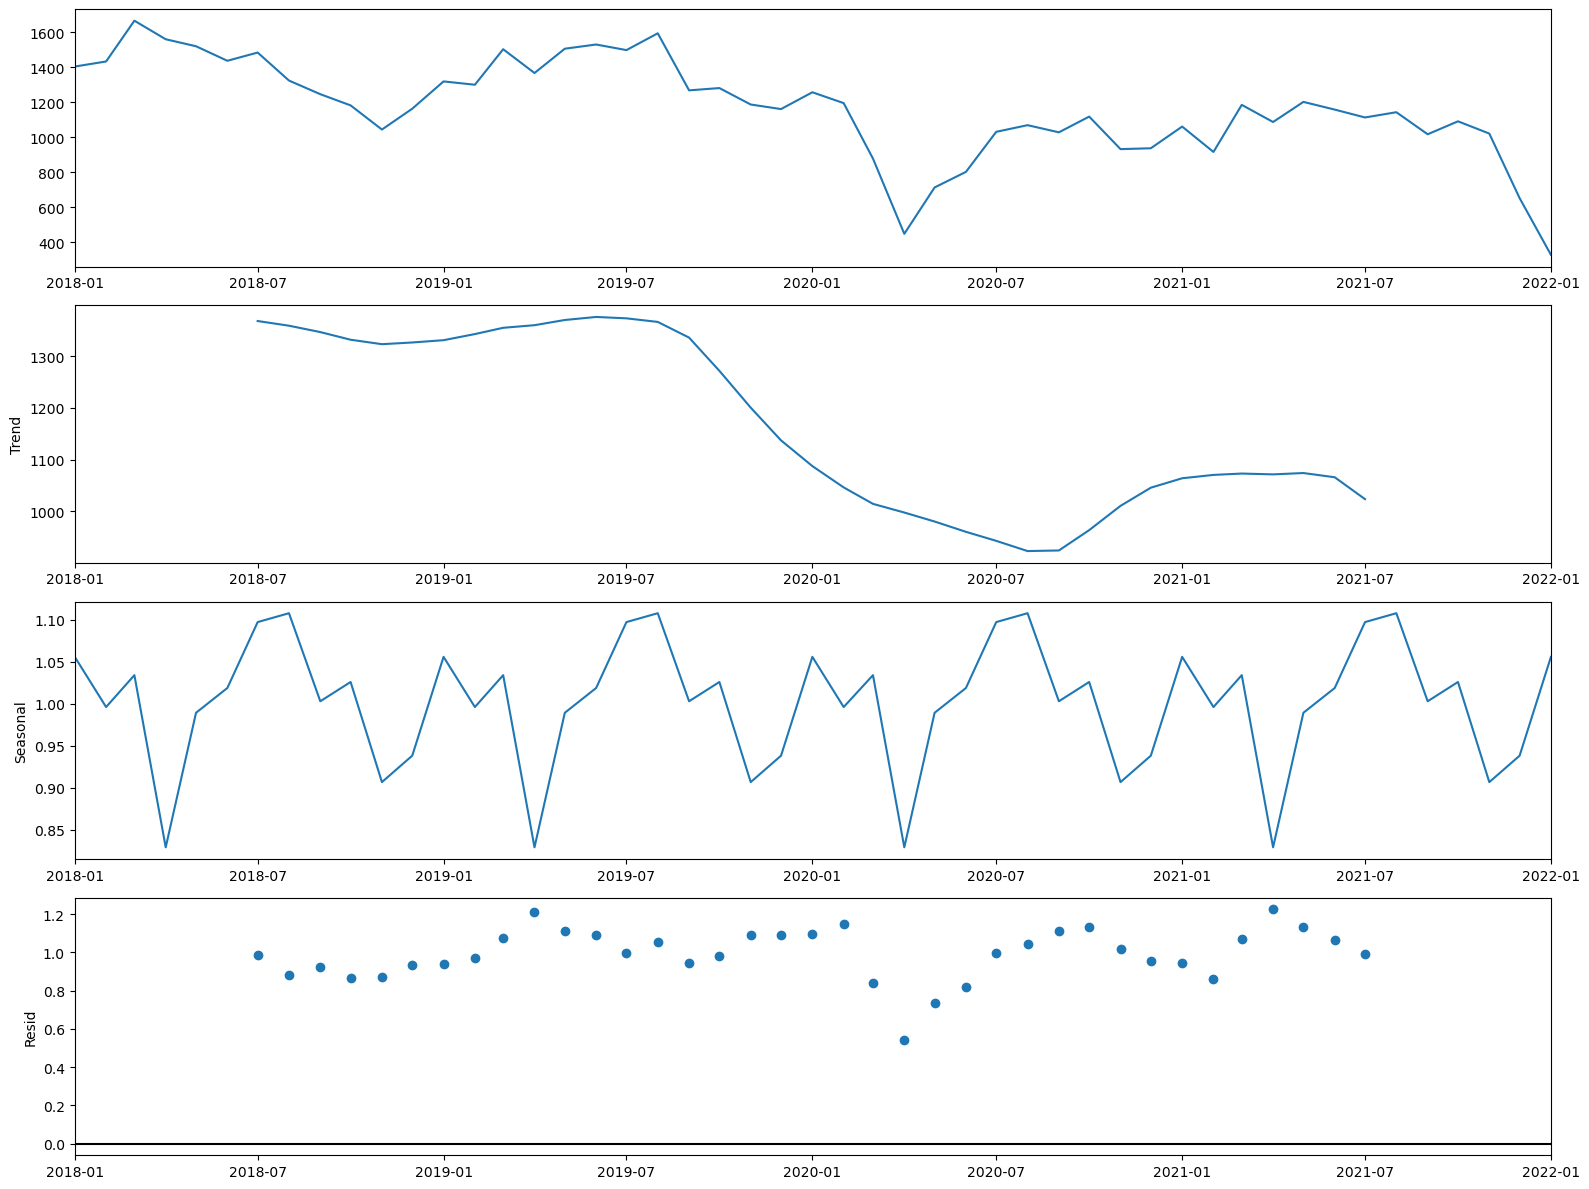

In [134]:
from statsmodels.tsa.seasonal import seasonal_decompose
multiplicative_decomposition = seasonal_decompose(tip_high_rated, model = 'multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

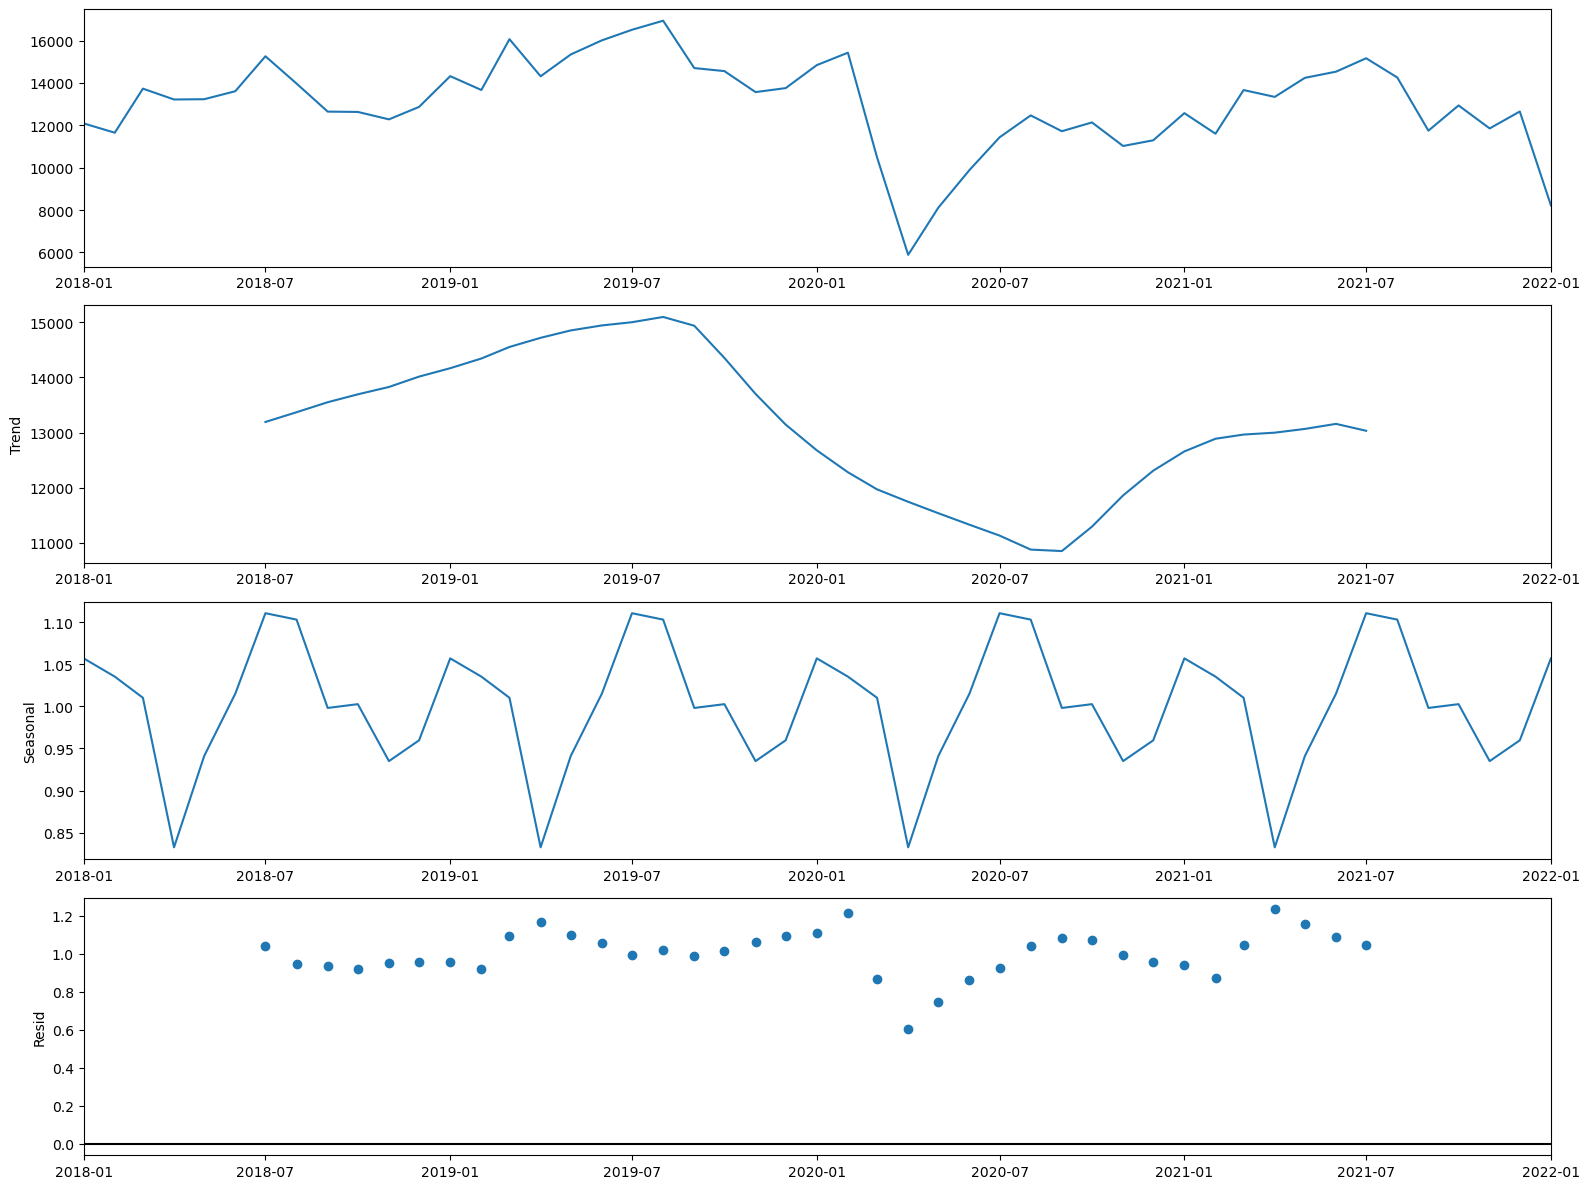

In [135]:
multiplicative_decomposition = seasonal_decompose(review_high_rated, model = 'multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

In [139]:
#analysing the correlation between sentiment and success metrics
sentiment_df = pd.read_sql_query(f"""SELECT b.business_id, AVG(b.stars) as avg_rating, SUM(b.review_count) AS review_count,
SUM(s.useful_count) AS useful_count,
SUM(s.funny_count) AS funny_count,
SUM(s.cool_count) AS cool_count
FROM
(SELECT business_id,
SUM(useful) AS useful_count,
SUM(funny) AS funny_count,
SUM(cool) AS cool_count
FROM review
GROUP BY business_id) AS s
JOIN business as b ON b.business_id = s.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY b.business_id
ORDER BY review_count
""", conn)

sentiment_df = remove_outliers(sentiment_df, 'review_count')
sentiment_df = remove_outliers(sentiment_df, 'useful_count')
sentiment_df = remove_outliers(sentiment_df, 'funny_count')
sentiment_df = remove_outliers(sentiment_df, 'cool_count')

In [141]:
sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

<AxesSubplot:>

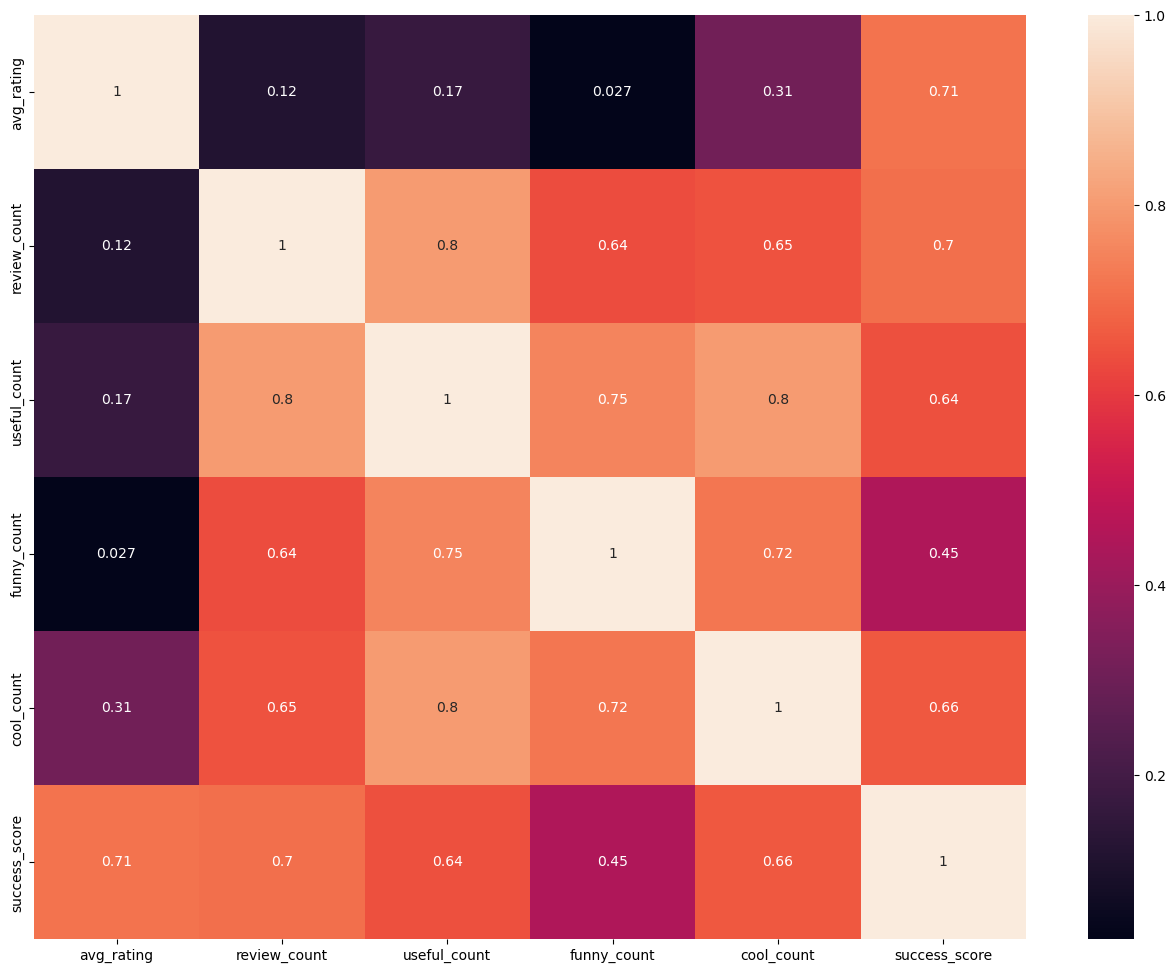

In [144]:
sns.heatmap(sentiment_df.corr(), annot = True)

In [158]:
#comparing user enagement between elite and non-elite users
elite_df = pd.read_sql_query("""
SELECT elite,
COUNT(*) AS review_count,
SUM(review_count) AS total_review_count
FROM
(SELECT 
    CASE
        WHEN elite = '' THEN 'Not Elite'
        ELSE 'Elite'
        END AS elite,
        u.review_count
    FROM user u) AS user_elite
    GROUP BY elite;
""", conn)

In [159]:
elite_df

,elite,review_count,total_review_count
0,Elite,91198,20484441
1,Not Elite,1896699,26021235


([<matplotlib.patches.Wedge at 0x15557f2b850>,
 [Text(0.2045175807287882, 1.0808203177091202, 'Elite'),
  Text(-0.20451758072878856, -1.0808203177091202, 'Not Elite')],
 [Text(0.11155504403388446, 0.5895383551140655, '44.05'),
  Text(-0.11155504403388465, -0.5895383551140655, '55.95')])

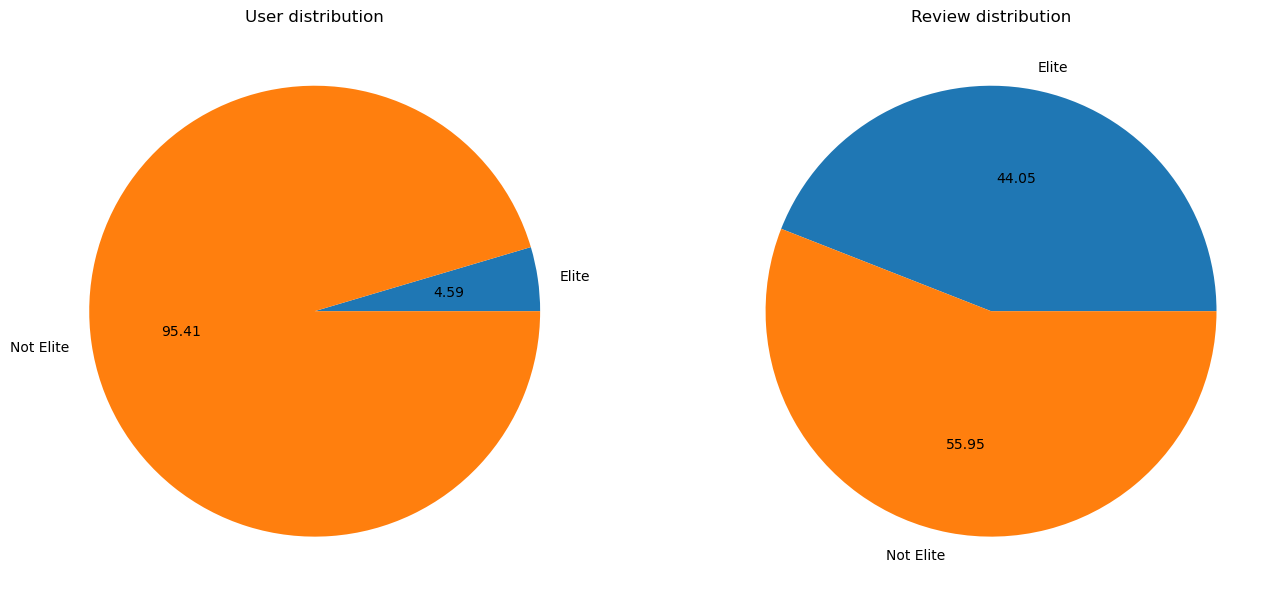

In [160]:
plt.subplot(1,2,1)
plt.title("User distribution")
plt.pie(elite_df['review_count'], labels = elite_df['elite'], autopct='%.2f')

plt.subplot(1,2,2)
plt.title("Review distribution")
plt.pie(elite_df['total_review_count'], labels = elite_df['elite'], autopct='%.2f')

In [164]:
#what are the busiest hours?

review_engagement = pd.read_sql_query(""" 
SELECT cast (strftime('%H', date) as integer) AS hour,
COUNT(*) AS review_count
FROM review
GROUP BY hour;
""", conn)

tip_engagement = pd.read_sql_query(""" 
SELECT cast (strftime('%H', date) as integer) AS hour,
COUNT(*) AS tip_count
FROM tip
GROUP BY hour;
""", conn)

checkin = pd.read_sql_query("""SELECT date FROM checkin""", conn)
checkin_engagement = []
for i in checkin['date']:
    checkin_engagement.extend([datetime.strptime(j.strip(),"%Y-%m-%d %H:%M:%S").strftime("%H") for j in i.split(',')])
    
checkin_engagement = pd.DataFrame(checkin_engagement).astype('int').groupby(0)[[0]].count()

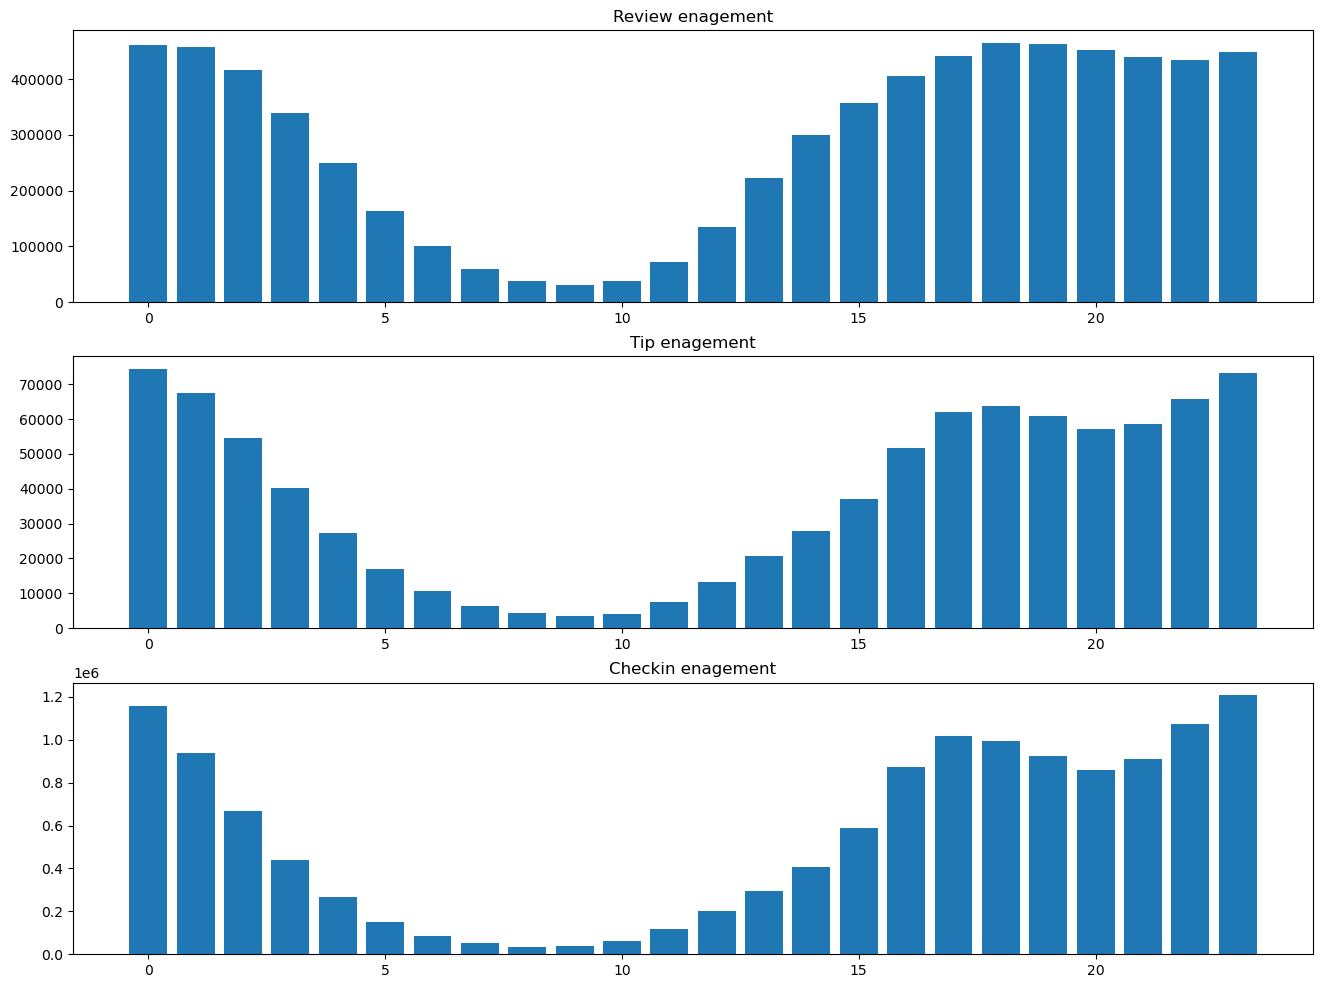

In [166]:
plt.subplot(3,1,1)
plt.title('Review enagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'])

plt.subplot(3,1,2)
plt.title('Tip enagement')
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'])

plt.subplot(3,1,3)
plt.title('Checkin enagement')
plt.bar(checkin_engagement.index, checkin_engagement[0])

plt.show()